## Retail Sales Forecasting & Business Insights
Goal: Predict future sales and uncover business insights for a retail store

In [32]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [33]:
# https://www.kaggle.com/datasets/aungpyaeap/supermarket-sales
df = pd.read_csv('Data/supermarket_sales - Sheet1.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


### Data Cleaning

In [34]:
df.info()
df.isnull().sum()
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [35]:
# Check unique values per column
for col in df.columns:
    print(col, ":", df[col].nunique())

Invoice ID : 1000
Branch : 3
City : 3
Customer type : 2
Gender : 2
Product line : 6
Unit price : 943
Quantity : 10
Tax 5% : 990
Total : 990
Date : 89
Time : 506
Payment : 3
cogs : 990
gross margin percentage : 1
gross income : 990
Rating : 61
Month : 3


### Exploratory Data Analysis

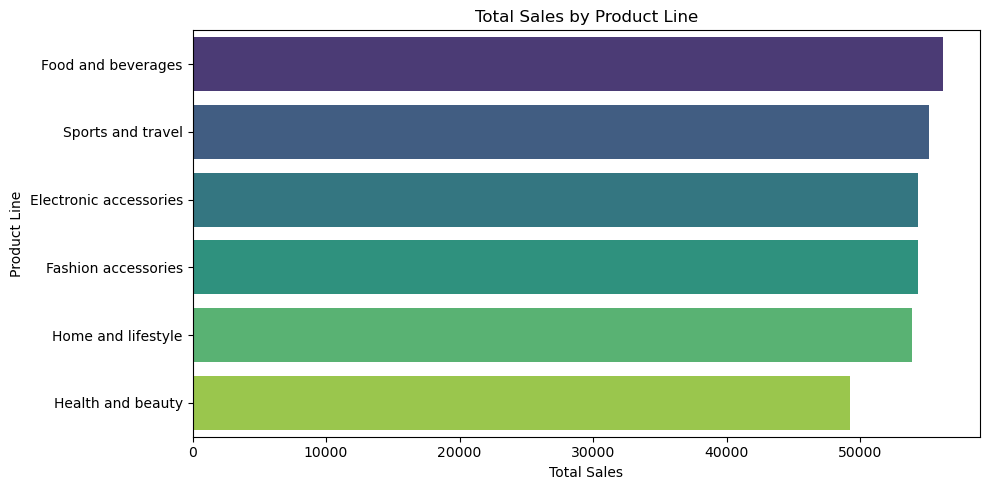

In [68]:
# Total sales by product line
total_sales = df.groupby('Product line')['Total'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,5))
sns.barplot(y='Product line', x='Total', data=total_sales, palette='viridis')
plt.title('Total Sales by Product Line')
plt.xlabel('Total Sales')
plt.ylabel('Product Line')
plt.tight_layout()
plt.show()

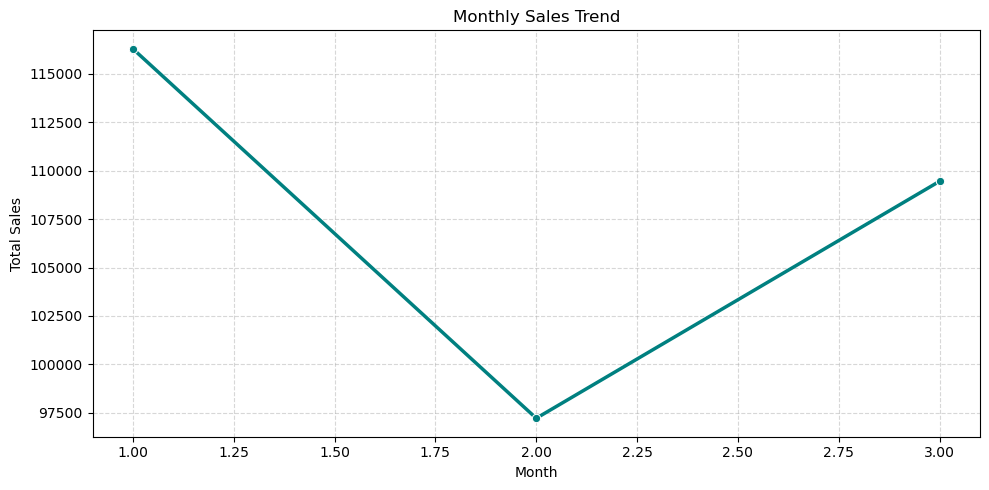

In [37]:
# 💡 Monthly sales trend
monthly_sales = df.groupby('Month')['Total'].sum().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(x='Month', y='Total', data=monthly_sales, marker='o', color='teal', linewidth=2.5)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

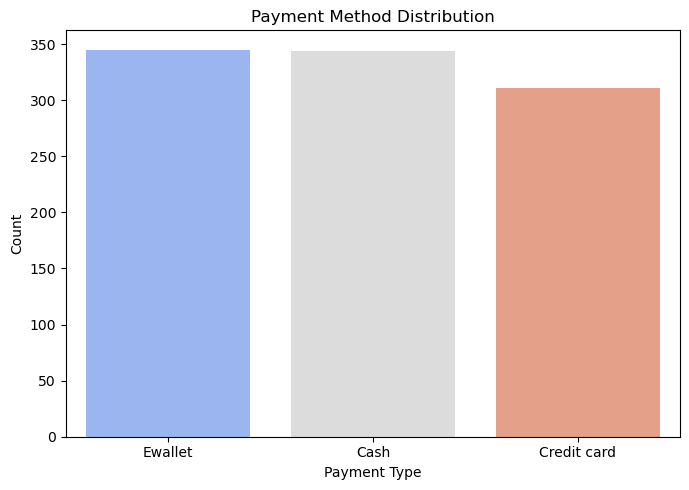

In [67]:
# Payment method distribution
plt.figure(figsize=(7,5))
sns.countplot(x='Payment', data=df, palette='coolwarm')
plt.title('Payment Method Distribution')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

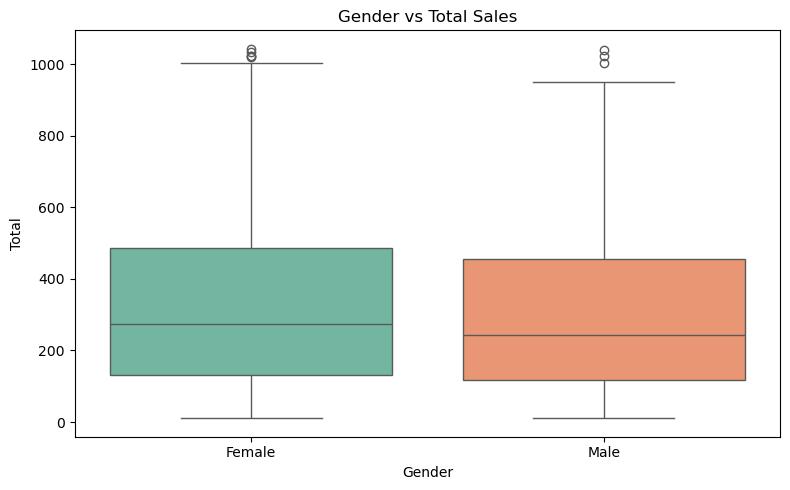

In [40]:
# Gender vs Sales comparison
plt.figure(figsize=(8,5))
sns.boxplot(x='Gender', y='Total', data=df, palette='Set2')
plt.title('Gender vs Total Sales')
plt.tight_layout()
plt.show()

### Predictive Modeling (Regression)

In [41]:
# Choose features
X = df[['Unit price', 'Quantity', 'Rating']]
y = df['Total']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 58.41433946805874
Root Mean Squared Error (RMSE): 78.7356883540165


### Visualization of Predictions

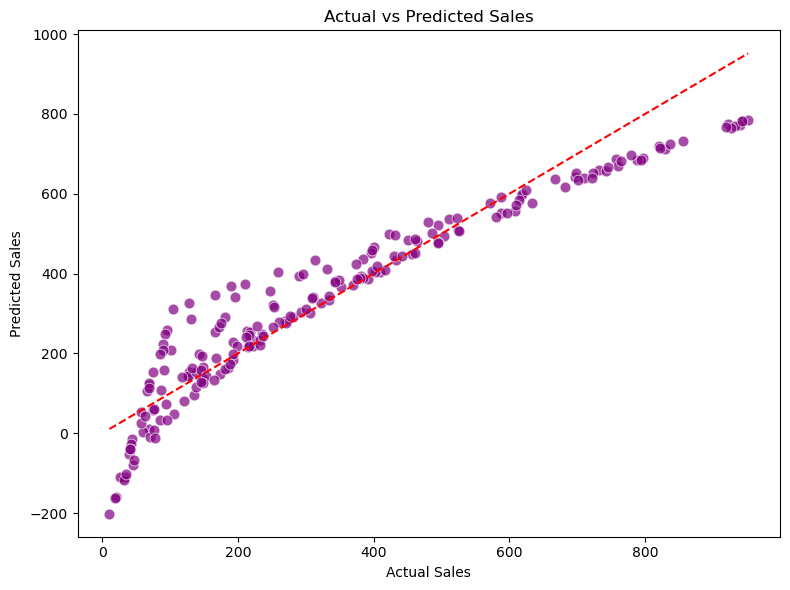

In [65]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='purple', s=60, edgecolor='white')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.tight_layout()
plt.show()

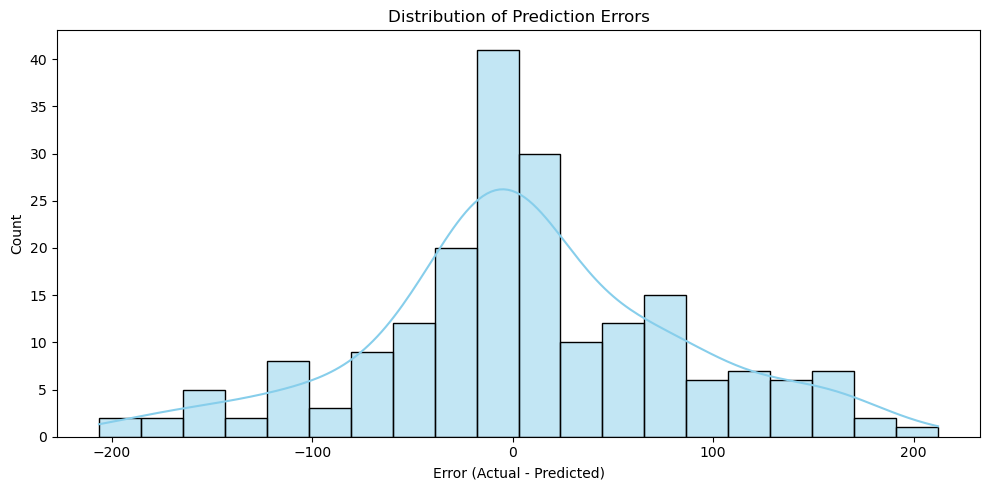

In [64]:
# Distribution of prediction errors
errors = y_test - y_pred
plt.figure(figsize=(10,5))
sns.histplot(errors, bins=20, kde=True, color='skyblue')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error (Actual - Predicted)')
plt.tight_layout()
plt.show()